# Analyse Rapport — Misinformatie Detectie
## Scriptie-analyse: SVM vs Logistic Regression vs BERT

In [7]:
import sys

In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('Klaar!')

Klaar!


## 1. Modelvergelijking — Hoofdresultaten

In [9]:
# Laad vergelijkingstabel
comparison = pd.read_csv('../results/model_comparison_test.csv')
print('=== MODELVERGELIJKING OP TESTSET ===')
print(comparison[['model','f1_macro','precision','recall','accuracy','auc_roc']]
      .sort_values('f1_macro', ascending=False)
      .to_string(index=False))

# Welk model wint?
best = comparison.loc[comparison['f1_macro'].idxmax(), 'model']
best_f1 = comparison['f1_macro'].max()
print(f'\n→ Beste model: {best} (F1-macro = {best_f1:.4f})')

=== MODELVERGELIJKING OP TESTSET ===
              model  f1_macro  precision   recall  accuracy  auc_roc
Logistic Regression  0.631443   0.631231 0.631718  0.637704 0.672721
               BERT  0.625849   0.630274 0.625048  0.639255 0.675493
                SVM  0.568976   0.606102 0.580388  0.613654 0.655829

→ Beste model: Logistic Regression (F1-macro = 0.6314)


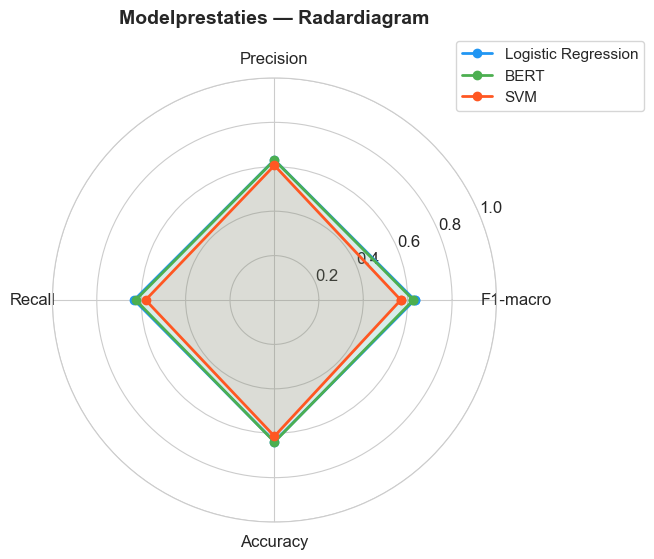

In [10]:
# Visuele vergelijking — radardiagram
metrics = ['f1_macro', 'precision', 'recall', 'accuracy']
labels  = ['F1-macro', 'Precision', 'Recall', 'Accuracy']
colors  = ['#2196F3', '#4CAF50', '#FF5722']

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (_, row), color in zip(comparison.iterrows(), colors):
    values = [row[m] for m in metrics] + [row[metrics[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['model'], color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_title('Modelprestaties — Radardiagram', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../results/figures/radar_vergelijking.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Foutanalyse — Waar gaan de modellen mis?

In [11]:
%pip install joblib transformers torch datasets scikit-learn


  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Gebruiker\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [12]:
import joblib

# Laad testset
test_df = pd.read_csv('../data/processed/test_combined.csv').dropna(subset=['clean_text'])
X_test  = test_df['clean_text'].tolist()
y_test  = test_df['label'].values

# Laad modellen en maak voorspellingen
models = {}
for name, path in [('SVM', '../results/svm/svm_model.joblib'),
                   ('LR',  '../results/lr/lr_model.joblib')]:
    try:
        models[name] = joblib.load(path)
        test_df[f'pred_{name}']  = models[name].predict(X_test)
        test_df[f'prob_{name}']  = models[name].predict_proba(X_test)[:, 1]
        test_df[f'error_{name}'] = (test_df['label'] != test_df[f'pred_{name}']).astype(int)
        print(f'{name} geladen: {test_df[f"error_{name}"].sum()} fouten op {len(test_df)} samples')
    except FileNotFoundError:
        print(f'{name} model niet gevonden op {path}')

# Probeer BERT toe te voegen
try:
    import torch
    from transformers import BertTokenizerFast, BertForSequenceClassification
    from torch.utils.data import DataLoader, TensorDataset

    bert_path = '../results/bert/best_model/'
    tokenizer = BertTokenizerFast.from_pretrained(bert_path)
    model_bert = BertForSequenceClassification.from_pretrained(bert_path)
    model_bert.eval()

    enc = tokenizer(X_test, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
    with torch.no_grad():
        out   = model_bert(**enc)
        probs = torch.softmax(out.logits, dim=-1)[:, 1].numpy()
        preds = out.logits.argmax(dim=-1).numpy()

    test_df['pred_BERT']  = preds
    test_df['prob_BERT']  = probs
    test_df['error_BERT'] = (test_df['label'] != preds).astype(int)
    models['BERT'] = None
    print(f'BERT geladen: {test_df["error_BERT"].sum()} fouten')
except Exception as e:
    print(f'BERT niet beschikbaar: {e}')

print(f'\nTestset: {len(test_df)} samples, {y_test.sum()} waar ({y_test.mean()*100:.1f}%)')

SVM geladen: 489 fouten op 1289 samples
LR geladen: 489 fouten op 1289 samples


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6349.88it/s]


BERT geladen: 465 fouten

Testset: 1289 samples, 733 waar (56.9%)


In [13]:
# Bekijk de berichten waar ALLE modellen het mis hebben
error_cols = [c for c in test_df.columns if c.startswith('error_')]
test_df['error_count'] = test_df[error_cols].sum(axis=1)

alle_mis = test_df[test_df['error_count'] == len(error_cols)].copy()
print(f'Berichten waar ALLE modellen fout zitten: {len(alle_mis)}')
print(f'  → {(alle_mis["label"] == 1).sum()} zijn in werkelijkheid WAAR')
print(f'  → {(alle_mis["label"] == 0).sum()} zijn in werkelijkheid ONWAAR')

print('\nVoorbeelden van moeilijke gevallen:')
cols_show = ['clean_text', 'label', 'char_length', 'source_trust_score', 'source']
cols_show = [c for c in cols_show if c in alle_mis.columns]
print(alle_mis[cols_show].head(10).to_string(index=False))

Berichten waar ALLE modellen fout zitten: 268
  → 72 zijn in werkelijkheid WAAR
  → 196 zijn in werkelijkheid ONWAAR

Voorbeelden van moeilijke gevallen:
                                                                                                                                                  clean_text  label  char_length  source_trust_score source
                                                                                        building a wall on the u.s.-mexico border will take literally years.      1           68                3.77   liar
                                                                                             wisconsin is on pace to double the number of layoffs this year.      0           63                1.00   liar
                                                                       suzanne bonamici supports a plan that will cut choice for medicare advantage seniors.      1           85                4.21   liar
       we know that more than 

In [14]:
# Venn-achtig overzicht: welke fouten overlappen?
if len(error_cols) >= 2:
    overlap_data = {}
    model_names = [c.replace('error_', '') for c in error_cols]

    for i, m1 in enumerate(model_names):
        for j, m2 in enumerate(model_names):
            if i < j:
                e1 = set(test_df[test_df[f'error_{m1}'] == 1].index)
                e2 = set(test_df[test_df[f'error_{m2}'] == 1].index)
                overlap = len(e1 & e2)
                print(f'Gedeelde fouten {m1} ∩ {m2}: {overlap} '
                      f'({overlap/len(test_df)*100:.1f}% van testset)')

Gedeelde fouten SVM ∩ LR: 381 (29.6% van testset)
Gedeelde fouten SVM ∩ BERT: 304 (23.6% van testset)
Gedeelde fouten LR ∩ BERT: 324 (25.1% van testset)


## 3. Factor 1 — Berichtlengte

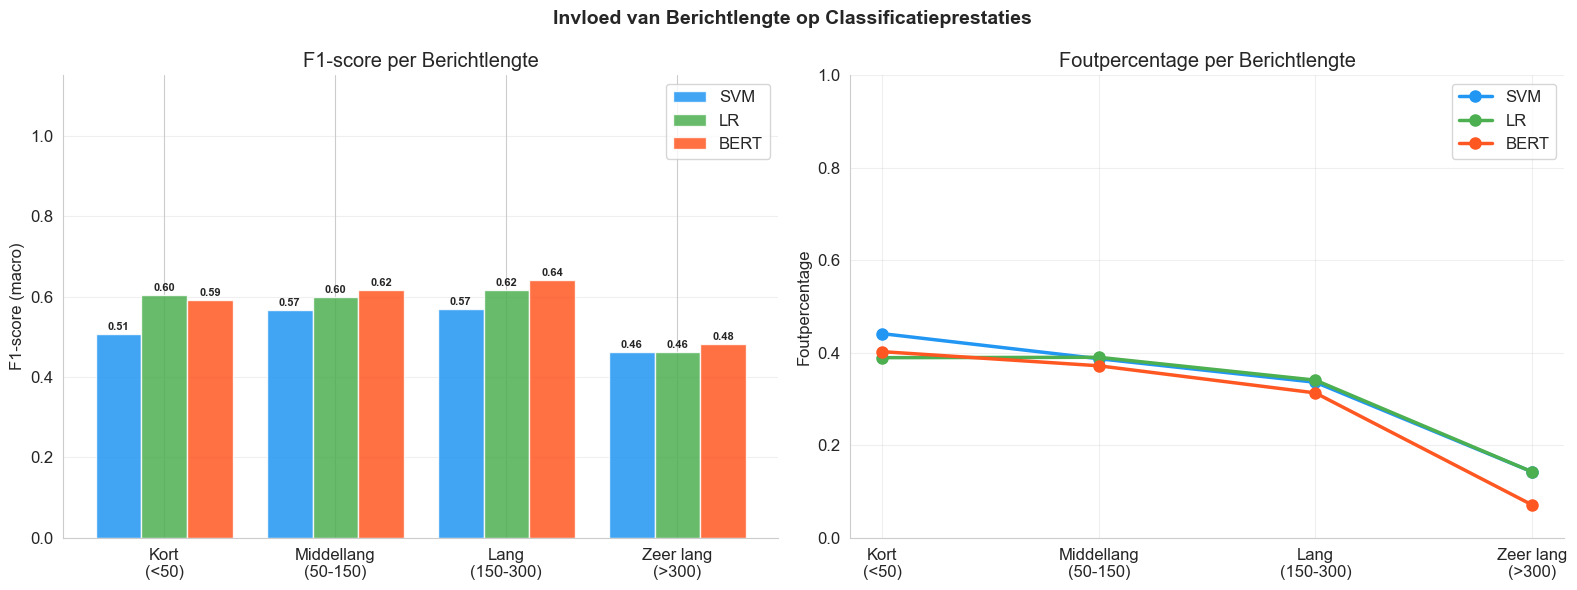


=== CHI-KWADRAAT TOETS: BERICHTLENGTE vs CLASSIFICATIEFOUT ===
SVM: χ²=6.558, df=3, p=0.0874  →  ✗ niet significant
LR: χ²=5.225, df=3, p=0.1560  →  ✗ niet significant
BERT: χ²=8.324, df=3, p=0.0398  →  ✓ SIGNIFICANT


In [15]:
from sklearn.metrics import f1_score

length_order = ['kort', 'middellang', 'lang', 'zeer_lang']
length_labels = ['Kort\n(<50)', 'Middellang\n(50-150)', 'Lang\n(150-300)', 'Zeer lang\n(>300)']
pred_cols = [c for c in test_df.columns if c.startswith('pred_')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 per lengtecategorie
ax = axes[0]
x = np.arange(len(length_order))
w = 0.8 / len(pred_cols)
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (col, color) in enumerate(zip(pred_cols, colors)):
    model_name = col.replace('pred_', '')
    f1_vals = []
    for cat in length_order:
        mask = test_df['length_category'] == cat
        if mask.sum() >= 5:
            f1 = f1_score(test_df.loc[mask, 'label'], test_df.loc[mask, col],
                          average='macro', zero_division=0)
        else:
            f1 = 0
        f1_vals.append(f1)
    bars = ax.bar(x + i*w, f1_vals, w, label=model_name, color=color, alpha=0.85)
    for bar, v in zip(bars, f1_vals):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + w*(len(pred_cols)-1)/2)
ax.set_xticklabels(length_labels)
ax.set_ylabel('F1-score (macro)')
ax.set_title('F1-score per Berichtlengte')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Foutpercentage per lengtecategorie
ax2 = axes[1]
counts = test_df.groupby('length_category').size()
for i, (col, color) in enumerate(zip(pred_cols, colors)):
    error_col = col.replace('pred_', 'error_')
    if error_col not in test_df.columns:
        continue
    model_name = col.replace('pred_', '')
    err_vals = [test_df[test_df['length_category']==cat][error_col].mean()
                for cat in length_order]
    ax2.plot(length_labels, err_vals, 'o-', label=model_name, color=color,
             linewidth=2.5, markersize=8)

ax2.set_ylabel('Foutpercentage')
ax2.set_title('Foutpercentage per Berichtlengte')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Invloed van Berichtlengte op Classificatieprestaties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/analyse_berichtlengte.png', dpi=150, bbox_inches='tight')
plt.show()

# Chi-kwadraat toets
print('\n=== CHI-KWADRAAT TOETS: BERICHTLENGTE vs CLASSIFICATIEFOUT ===')
for col in pred_cols:
    error_col = col.replace('pred_', 'error_')
    if error_col not in test_df.columns:
        continue
    model_name = col.replace('pred_', '')
    ct = pd.crosstab(test_df['length_category'], test_df[error_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '✓ SIGNIFICANT' if p < 0.05 else '✗ niet significant'
    print(f'{model_name}: χ²={chi2:.3f}, df={dof}, p={p:.4f}  →  {sig}')

## 4. Factor 2 — Bronbetrouwbaarheid

=== VERDELING BRONBETROUWBAARHEID ===
trust_cat
Middel (3.5-6.5)    686
Laag (1-3.5)        474
Hoog (6.5-10)       129
Name: count, dtype: int64


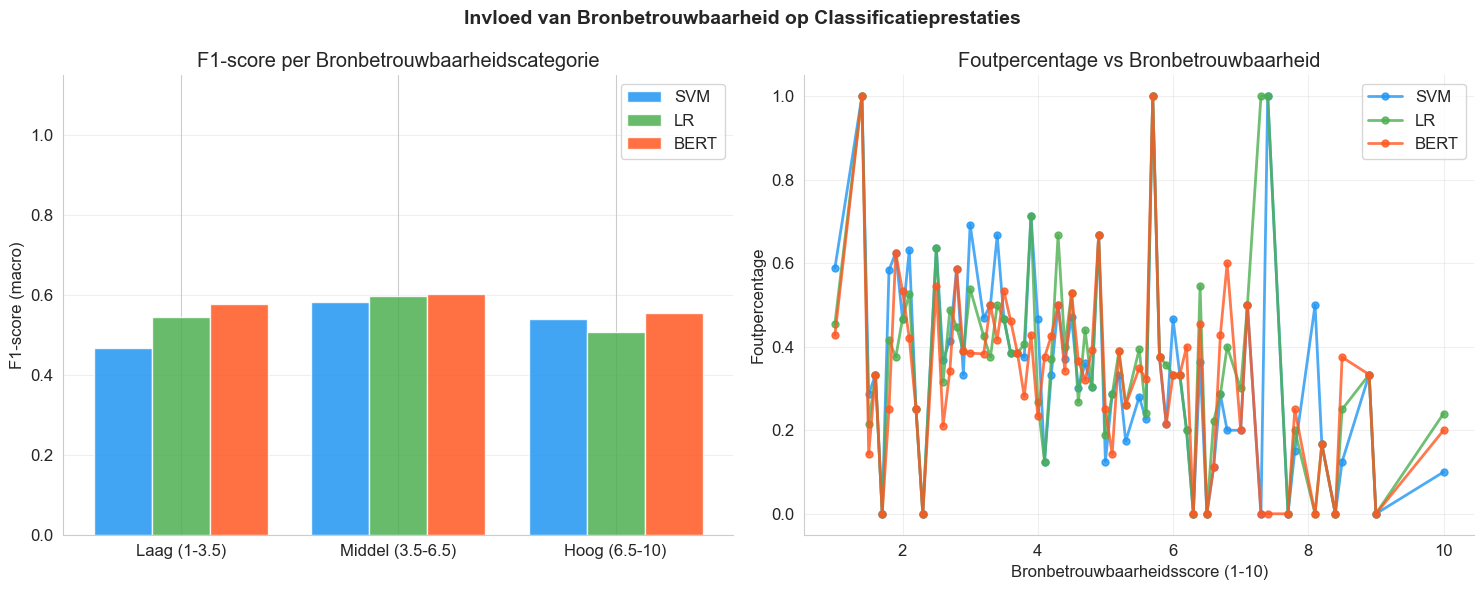


=== ANOVA TOETS: BRONBETROUWBAARHEID vs CLASSIFICATIEFOUT ===
SVM: F=45.872, p=0.0000  →  ✓ SIGNIFICANT
LR: F=9.832, p=0.0001  →  ✓ SIGNIFICANT
BERT: F=7.477, p=0.0006  →  ✓ SIGNIFICANT


In [16]:
# Categoriseer bronbetrouwbaarheid
test_df['trust_cat'] = pd.cut(
    test_df['source_trust_score'],
    bins=[0, 3.5, 6.5, 10],
    labels=['Laag (1-3.5)', 'Middel (3.5-6.5)', 'Hoog (6.5-10)']
)

print('=== VERDELING BRONBETROUWBAARHEID ===')
print(test_df['trust_cat'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
trust_cats = ['Laag (1-3.5)', 'Middel (3.5-6.5)', 'Hoog (6.5-10)']
x = np.arange(len(trust_cats))
w = 0.8 / len(pred_cols)

for i, (col, color) in enumerate(zip(pred_cols, colors)):
    model_name = col.replace('pred_', '')
    f1_vals = []
    for cat in trust_cats:
        mask = test_df['trust_cat'].astype(str) == cat
        if mask.sum() >= 5:
            f1 = f1_score(test_df.loc[mask,'label'], test_df.loc[mask,col],
                          average='macro', zero_division=0)
        else:
            f1 = 0
        f1_vals.append(f1)
    axes[0].bar(x + i*w, f1_vals, w, label=model_name, color=color, alpha=0.85)

axes[0].set_xticks(x + w*(len(pred_cols)-1)/2)
axes[0].set_xticklabels(trust_cats)
axes[0].set_ylabel('F1-score (macro)')
axes[0].set_title('F1-score per Bronbetrouwbaarheidscategorie')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Scatterplot: trust score vs foutpercentage (per model)
for col, color in zip(pred_cols, colors):
    error_col = col.replace('pred_', 'error_')
    if error_col not in test_df.columns:
        continue
    model_name = col.replace('pred_', '')
    trust_err = test_df.groupby(test_df['source_trust_score'].round(1))[error_col].mean()
    axes[1].plot(trust_err.index, trust_err.values, 'o-', label=model_name,
                 color=color, linewidth=2, markersize=5, alpha=0.8)

axes[1].set_xlabel('Bronbetrouwbaarheidsscore (1-10)')
axes[1].set_ylabel('Foutpercentage')
axes[1].set_title('Foutpercentage vs Bronbetrouwbaarheid')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Invloed van Bronbetrouwbaarheid op Classificatieprestaties',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/analyse_bronbetrouwbaarheid.png', dpi=150, bbox_inches='tight')
plt.show()

# ANOVA toets
print('\n=== ANOVA TOETS: BRONBETROUWBAARHEID vs CLASSIFICATIEFOUT ===')
for col in pred_cols:
    error_col = col.replace('pred_', 'error_')
    if error_col not in test_df.columns:
        continue
    model_name = col.replace('pred_', '')
    groups = [test_df[test_df['trust_cat'].astype(str)==cat][error_col].dropna().values
              for cat in trust_cats if len(test_df[test_df['trust_cat'].astype(str)==cat]) >= 5]
    if len(groups) >= 2:
        f, p = stats.f_oneway(*groups)
        sig = '✓ SIGNIFICANT' if p < 0.05 else '✗ niet significant'
        print(f'{model_name}: F={f:.3f}, p={p:.4f}  →  {sig}')

## 5. Factor 3 — Taalgebruik

In [17]:
features    = ['exclamation_count', 'question_count', 'caps_ratio', 'url_present', 'word_count']
feat_labels = ['Uitroeptekens', 'Vraagtekens', 'Hoofdletterverhouding', 'URL aanwezig', 'Woordaantal']

print('=== MANN-WHITNEY U TOETS: TAALKENMERKEN vs CLASSIFICATIEFOUT ===')
results_rows = []

for col in pred_cols:
    error_col = col.replace('pred_', 'error_')
    if error_col not in test_df.columns:
        continue
    model_name = col.replace('pred_', '')
    print(f'\n{model_name}:')
    for feat, label in zip(features, feat_labels):
        if feat not in test_df.columns:
            continue
        correct   = test_df[test_df[error_col]==0][feat].dropna()
        incorrect = test_df[test_df[error_col]==1][feat].dropna()
        if len(correct) >= 5 and len(incorrect) >= 5:
            stat, p = stats.mannwhitneyu(correct, incorrect, alternative='two-sided')
            sig = '✓ SIG' if p < 0.05 else ''
            print(f'  {label:30s}: correct_gem={correct.mean():.3f}, '
                  f'fout_gem={incorrect.mean():.3f}, p={p:.4f}  {sig}')
            results_rows.append({'model': model_name, 'kenmerk': label,
                                  'correct_gem': correct.mean(),
                                  'fout_gem': incorrect.mean(), 'p_waarde': p,
                                  'significant': p < 0.05})

taal_df = pd.DataFrame(results_rows)
taal_df.to_csv('../results/factor_taalgebruik_statistieken.csv', index=False)
print('\nResultaten opgeslagen: results/factor_taalgebruik_statistieken.csv')

=== MANN-WHITNEY U TOETS: TAALKENMERKEN vs CLASSIFICATIEFOUT ===

SVM:
  Uitroeptekens                 : correct_gem=0.004, fout_gem=0.006, p=0.5422  
  Vraagtekens                   : correct_gem=0.028, fout_gem=0.014, p=0.4588  
  Hoofdletterverhouding         : correct_gem=0.000, fout_gem=0.000, p=0.1658  
  URL aanwezig                  : correct_gem=0.014, fout_gem=0.008, p=0.3660  
  Woordaantal                   : correct_gem=19.611, fout_gem=18.239, p=0.0060  ✓ SIG

LR:
  Uitroeptekens                 : correct_gem=0.005, fout_gem=0.004, p=0.8164  
  Vraagtekens                   : correct_gem=0.030, fout_gem=0.010, p=0.0958  
  Hoofdletterverhouding         : correct_gem=0.000, fout_gem=0.000, p=0.1658  
  URL aanwezig                  : correct_gem=0.014, fout_gem=0.008, p=0.3660  
  Woordaantal                   : correct_gem=19.430, fout_gem=18.536, p=0.1353  

BERT:
  Uitroeptekens                 : correct_gem=0.006, fout_gem=0.002, p=0.3216  
  Vraagtekens               

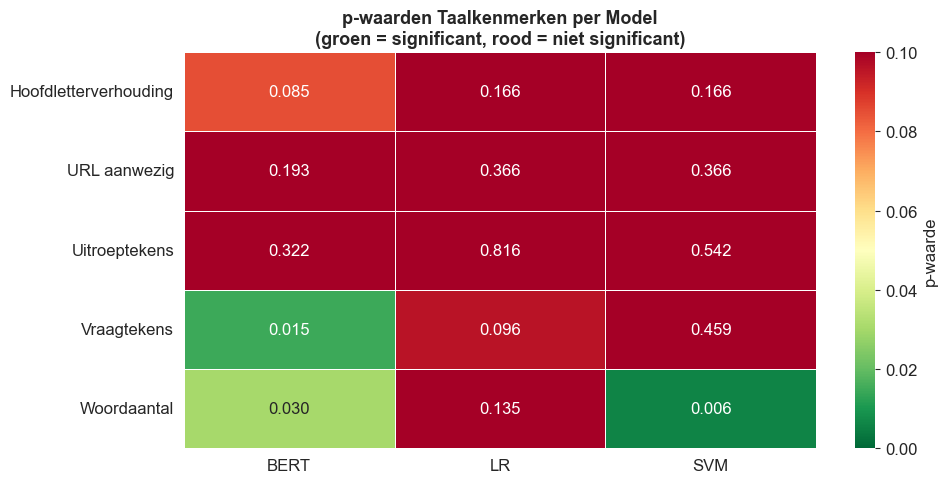

In [18]:
# Heatmap: significantie van alle factoren per model
if not taal_df.empty:
    pivot = taal_df.pivot(index='kenmerk', columns='model', values='p_waarde')
    sig_pivot = (pivot < 0.05).astype(int)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
                ax=ax, linewidths=0.5, cbar_kws={'label': 'p-waarde'},
                vmin=0, vmax=0.1)
    ax.set_title('p-waarden Taalkenmerken per Model\n(groen = significant, rood = niet significant)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('../results/figures/heatmap_taalkenmerken.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. BERT Trainingsverloop

 epoch  train_loss  f1_macro  precision   recall
     1    0.666023  0.631805   0.638258 0.632883
     2    0.607314  0.605717   0.656281 0.621161
     3    0.492220  0.631168   0.634913 0.631579
     4    0.373128  0.612143   0.629110 0.617073


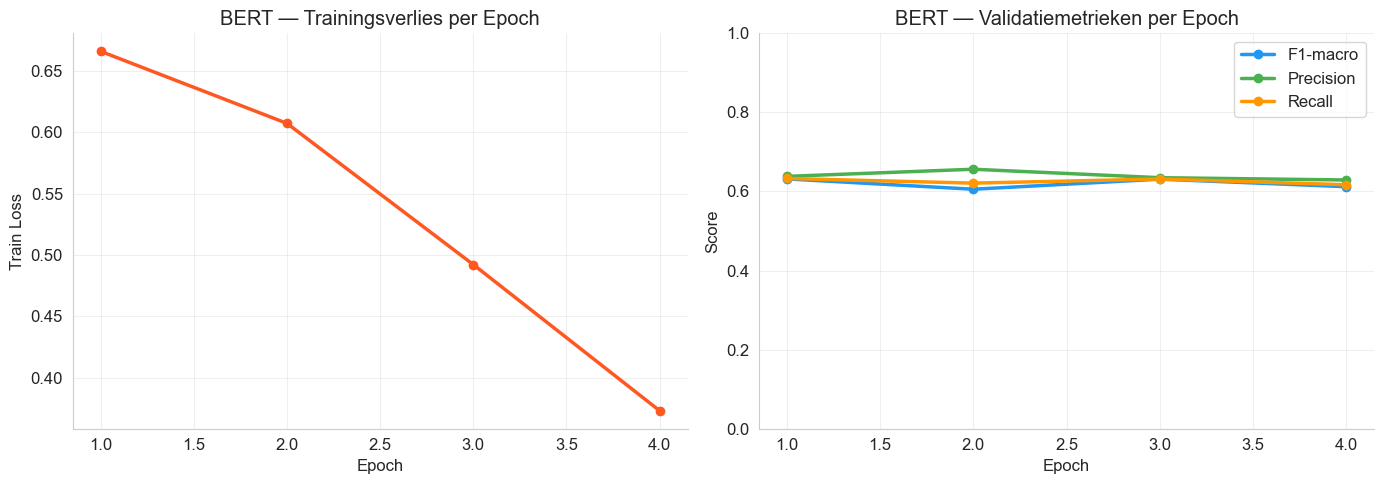

In [19]:
import os
bert_history_path = '../results/bert/bert_training_history.csv'
if os.path.exists(bert_history_path):
    history = pd.read_csv(bert_history_path)
    print(history[['epoch','train_loss','f1_macro','precision','recall']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['epoch'], history['train_loss'], 'o-', color='#FF5722', linewidth=2.5)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Train Loss')
    axes[0].set_title('BERT — Trainingsverlies per Epoch')
    axes[0].grid(alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    for metric, color, label in [('f1_macro','#2196F3','F1-macro'),
                                   ('precision','#4CAF50','Precision'),
                                   ('recall','#FF9800','Recall')]:
        if metric in history.columns:
            axes[1].plot(history['epoch'], history[metric], 'o-',
                         color=color, linewidth=2.5, label=label)

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title('BERT — Validatiemetrieken per Epoch')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('../results/figures/bert_trainingsverloop.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Geen BERT trainingsgeschiedenis gevonden.')

## 7. Samenvatting voor Scriptie

In [20]:
print('='*60)
print('SAMENVATTING — SCRIPTIERESULTATEN')
print('='*60)

comparison = pd.read_csv('../results/model_comparison_test.csv')
best_row = comparison.loc[comparison['f1_macro'].idxmax()]

print(f'\n1. MODELVERGELIJKING')
for _, row in comparison.sort_values('f1_macro', ascending=False).iterrows():
    print(f'   {row["model"]:25s}: F1={row["f1_macro"]:.4f}, '
          f'Precision={row["precision"]:.4f}, Recall={row["recall"]:.4f}')

print(f'\n2. BESTE MODEL: {best_row["model"]} (F1={best_row["f1_macro"]:.4f})')

# Verschil BERT vs traditioneel
bert_f1 = comparison[comparison['model']=='BERT']['f1_macro'].values
svm_f1  = comparison[comparison['model']=='SVM']['f1_macro'].values
if len(bert_f1) and len(svm_f1):
    diff = bert_f1[0] - svm_f1[0]
    print(f'   BERT vs SVM verschil: {diff:+.4f} F1-punten')

print('\n3. FACTORANALYSE (p < 0.05 = significant effect)')
if os.path.exists('../results/factor_taalgebruik_statistieken.csv'):
    taal = pd.read_csv('../results/factor_taalgebruik_statistieken.csv')
    sig = taal[taal['significant'] == True][['model','kenmerk','p_waarde']]
    if len(sig):
        print(sig.to_string(index=False))
    else:
        print('   Geen significante taalkenmerken gevonden.')

print('\n4. GEGENEREERDE FIGUREN')
for f in sorted(os.listdir('../results/figures/')):
    if f.endswith('.png'):
        print(f'   results/figures/{f}')

SAMENVATTING — SCRIPTIERESULTATEN

1. MODELVERGELIJKING
   Logistic Regression      : F1=0.6314, Precision=0.6312, Recall=0.6317
   BERT                     : F1=0.6258, Precision=0.6303, Recall=0.6250
   SVM                      : F1=0.5690, Precision=0.6061, Recall=0.5804

2. BESTE MODEL: Logistic Regression (F1=0.6314)
   BERT vs SVM verschil: +0.0569 F1-punten

3. FACTORANALYSE (p < 0.05 = significant effect)
model     kenmerk  p_waarde
  SVM Woordaantal  0.006023
 BERT Vraagtekens  0.014565
 BERT Woordaantal  0.030299

4. GEGENEREERDE FIGUREN
   results/figures/analyse_berichtlengte.png
   results/figures/analyse_bronbetrouwbaarheid.png
   results/figures/bert_trainingsverloop.png
   results/figures/confusion_matrices.png
   results/figures/eda_berichtlengte.png
   results/figures/eda_bronbetrouwbaarheid.png
   results/figures/eda_correlatiematrix.png
   results/figures/eda_labelbalans.png
   results/figures/eda_wordclouds.png
   results/figures/f1_per_lengte.png
   results/figure